In [1]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\zero7\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
import os
import cv2
import numpy as np
import torch
import yaml
import shutil
import random
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
import pandas as pd

device = 'cpu'
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
print(f"Using device: {device}")

Using device: cuda


In [3]:
def prepare_dataset(root = "./data"):
    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(root, split, 'images')
        label_dir = os.path.join(root, split, 'labels')
        
        if not os.path.exists(img_dir):
            print(f"Warning: {img_dir} not found")
        if not os.path.exists(label_dir):
            print(f"Warning: {label_dir} not found")
        
        images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))] if os.path.exists(img_dir) else []
        labels = [f for f in os.listdir(label_dir) if f.endswith('.txt')] if os.path.exists(label_dir) else []
        
        print(f"{split}: {len(images)} images, {len(labels)} labels")
    
    data_yaml = {
        'path': os.path.abspath(root),
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'nc': 2,
        'names': ['smoke', 'fire']
    }
    
    yaml_path = os.path.join(root, 'data.yaml')
    with open(yaml_path, 'w') as f:
        yaml.dump(data_yaml, f, default_flow_style=False)
    
    print(f"\nCreated {yaml_path}")
    print("Dataset structure is ready for YOLO!")
    
    return yaml_path

In [4]:
yaml_path = prepare_dataset()

train: 14122 images, 14122 labels
val: 3099 images, 3099 labels
test: 4306 images, 4306 labels

Created ./data\data.yaml
Dataset structure is ready for YOLO!


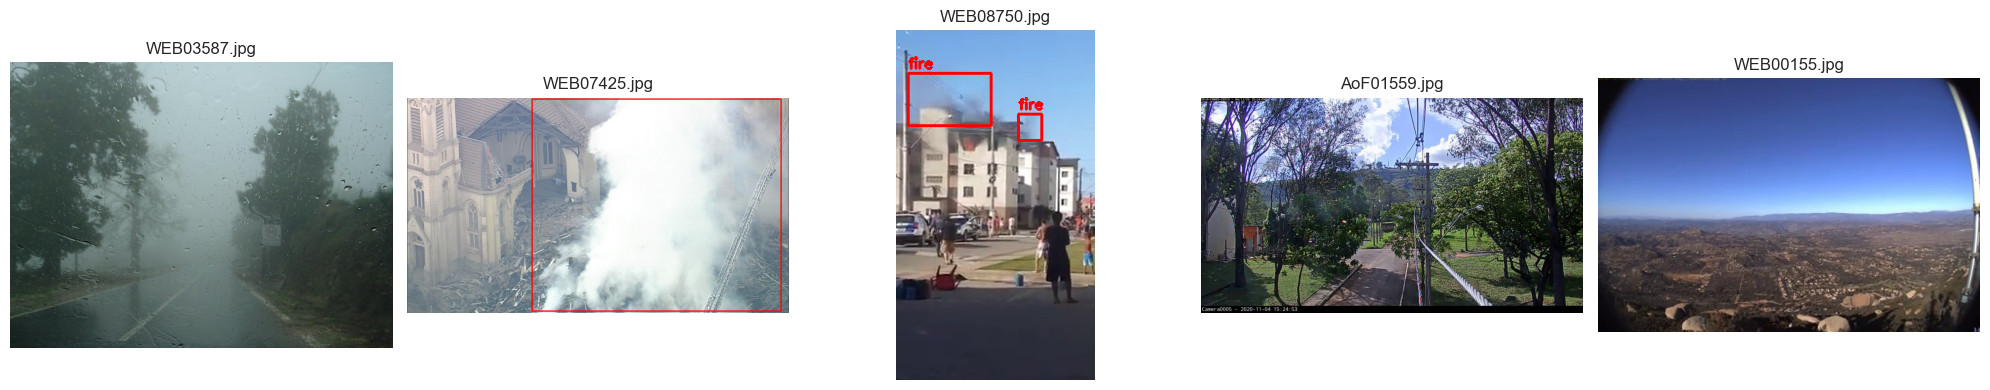

In [5]:
def visualize_samples(data_root='./data', num_samples=5):
    colors = {
        0: (255, 0, 0),
        1: (128, 128, 128)
    }
    
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 4))
    
    train_img_dir = os.path.join(data_root, 'train', 'images')
    train_label_dir = os.path.join(data_root, 'train', 'labels')
    
    images = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(images, min(num_samples, len(images)))
    
    for idx, img_file in enumerate(samples):
        img_path = os.path.join(train_img_dir, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        label_file = img_file.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
        label_path = os.path.join(train_label_dir, label_file)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(float(parts[0]))
                        x_center = float(parts[1])
                        y_center = float(parts[2])
                        width = float(parts[3])
                        height = float(parts[4])
                        
                        x1 = int((x_center - width/2) * w)
                        y1 = int((y_center - height/2) * h)
                        x2 = int((x_center + width/2) * w)
                        y2 = int((y_center + height/2) * h)
                        
                        color = colors.get(class_id, (0, 255, 0))
                        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                        
                        label = 'fire' if class_id == 1 else 'smoke'
                        cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f'{img_file}')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_samples('./data', num_samples=5) 

In [7]:
def train_yolo_model(yaml_path, epochs=100, imgsz=640, batch_size=16, model_size='m'):  
    print("="*50)
    print("STARTING YOLO TRAINING")
    print("="*50)
    
    model_name = f'yolov8{model_size}.pt'
    
    model = YOLO(model_name)
    
    results = model.train(
        data=yaml_path,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch_size,
        device=device,
        workers=4,
        lr0=0.01,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3,
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,
        box=7.5,
        cls=0.5,
        dfl=1.5,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=0.0,
        translate=0.1,
        scale=0.5,
        shear=0.0,
        perspective=0.0,
        flipud=0.0,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.0,
        copy_paste=0.0,
        patience=20,
        save=True,
        save_period=10,
        project='fire_smoke_detection',
        name=f'yolov8{model_size}_training',
        exist_ok=True,
        pretrained=True,
        optimizer='AdamW',
        verbose=True,
        seed=42,
        deterministic=True,
        single_cls=False,
        rect=False,
        cos_lr=True,
        close_mosaic=10,
        resume=False,
        amp=True,
        fraction=1.0,
        profile=False,
        freeze=None,
        multi_scale=False,
        overlap_mask=True,
        mask_ratio=4,
        dropout=0.0,
        val=True,
        split='val',
        save_json=False,
        save_hybrid=False,
        conf=None,
        iou=0.7,
        max_det=300,
        half=False,
        dnn=False,
        plots=True,
        source=None,
        vid_stride=1,
        stream_buffer=False,
        line_width=3,
        visualize=False,
        augment=False,
        agnostic_nms=False,
        classes=None,
        retina_masks=False,
        embed=None,
        show=False,
        save_frames=False,
        save_txt=False,
        save_conf=False,
        save_crop=False,
        show_labels=True,
        show_conf=True,
        show_boxes=True,
        format='torchscript',
        keras=False,
        optimize=False,
        int8=False,
        dynamic=False,
        simplify=True,
        opset=None,
        workspace=4,
        nms=False,
    )
    
    print("\nTraining completed!")
    
    return model

model = train_yolo_model(yaml_path, epochs=100, batch_size=16, model_size='m')  

STARTING YOLO TRAINING
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.14  Python-3.12.10 torch-2.7.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=3, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8m_training, nbs=64, 